# 06 — Combined Development Candidate Portfolio

## tl;dr

The equal-weight candidate portfolio returned 11.0% annualized at 6.1% volatility, with a 1.81 Sharpe and 4.6% maximum drawdown across 226 predefined development-validation sessions. Three of four folds were positive. The causal volatility-balanced version returned 14.1% at 10.0% volatility.

The funded research sleeves are **screened CL linear trend** and the **moving-average mean-reversion family**. This is a development candidate, not an unbiased out-of-sample or live result. The locked evaluation year remains untouched.

## Context & Methods

This notebook answers whether the existing costed strategy research contains a useful portfolio candidate after grouping related variations. Fifty session mean-reversion rules are first equal-weighted within five economic families; parameter-rich families therefore receive no extra vote. Distinct trend, breakout, and intraday sleeves each receive one vote.

A deliberately permissive development gate funds a sleeve when aggregate return is positive and at least two of four predefined folds are positive. Rejected sleeves remain visible in the diagnostic all-sleeves portfolio. No FDR gate is used.

### Key Assumptions

- All source strategy returns are net of their modeled costs and execution delays.
- Daily arithmetic return, sample volatility, and 252-session annualization are used.
- Causal volatility scaling uses only trailing returns, shifted one session.
- Candidate selection and candidate scoring use the same development folds. This selection bias requires a future locked sequential evaluation before promotion.
- CL was previously selected after reviewing these development folds, so its headline Sharpe must not be presented as untouched OOS performance.

## Data

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'outputs' else Path.cwd()
CANDIDATE = ROOT / 'data/processed/candidate_portfolio'
PANEL_PATH = ROOT / 'data/processed/research/development_session_panel.parquet'
FEATURE_PATH = ROOT / 'data/processed/features/development_session_features.parquet'
FOLD_PATH = ROOT / 'outputs/development_walk_forward_folds.csv'

panel = pd.read_parquet(PANEL_PATH)
features = pd.read_parquet(FEATURE_PATH)
folds = pd.read_csv(FOLD_PATH)
sleeves = pd.read_parquet(CANDIDATE / 'sleeve_returns.parquet')
portfolios = pd.read_parquet(CANDIDATE / 'portfolio_returns.parquet')
sleeve_summary = pd.read_csv(CANDIDATE / 'sleeve_aggregate_summary.csv')
portfolio_summary = pd.read_csv(CANDIDATE / 'portfolio_aggregate_summary.csv')
portfolio_folds = pd.read_csv(CANDIDATE / 'portfolio_fold_summary.csv')

### Source-panel QA

In [2]:
quality = pd.DataFrame({
    'check': [
        'development rows', 'development symbols', 'first session', 'last session',
        'duplicate date-symbol keys', 'null close-to-close returns',
        'duplicate feature keys', 'complete feature rows', 'portfolio return nulls'
    ],
    'result': [
        len(panel), panel['symbol'].nunique(), panel['trading_date'].min().date(),
        panel['trading_date'].max().date(),
        int(panel.duplicated(['trading_date', 'symbol']).sum()),
        int(panel['close_to_close_return'].isna().sum()),
        int(features.duplicated(['trading_date', 'symbol']).sum()),
        int(features['feature_set_complete'].sum()),
        int(portfolios.isna().sum().sum()),
    ]
})
quality

,check,result
0,development rows,3673
1,development symbols,5
2,first session,2022-10-12
3,last session,2025-08-15
4,duplicate date-symbol keys,0
5,null close-to-close returns,5
6,duplicate feature keys,0
7,complete feature rows,3073
8,portfolio return nulls,0


The five null close-to-close returns are the expected first observation for each of the five symbols. The 600 incomplete feature rows are warm-up observations and remain explicit rather than being imputed. CL sleeve returns are intentionally null outside the 226 validation sessions because that model only produced outer-fold forecasts.

## Results

In [3]:
portfolio_summary[[
    'strategy', 'sessions', 'annualized_return', 'annualized_volatility', 'sharpe',
    'maximum_drawdown', 'positive_folds', 'research_status'
]].round(4)

,strategy,sessions,annualized_return,annualized_volatility,sharpe,maximum_drawdown,positive_folds,research_status
0,candidate_sleeves_equal_weight,226,0.1101,0.0609,1.8082,-0.0462,3,candidate
1,candidate_sleeves_causal_volatility_balanced,226,0.1407,0.0997,1.4114,-0.0926,3,candidate
2,all_sleeves_equal_weight,226,-0.0079,0.0167,-0.4709,-0.0279,2,research_further
3,all_sleeves_causal_volatility_balanced,226,-0.0388,0.0598,-0.6482,-0.1019,2,research_further


In [4]:
sleeve_summary[[
    'strategy', 'annualized_return', 'annualized_volatility', 'sharpe',
    'maximum_drawdown', 'positive_folds', 'research_status'
]].round(4)

,strategy,annualized_return,annualized_volatility,sharpe,maximum_drawdown,positive_folds,research_status
0,ml_cl_trend,0.1919,0.0933,2.0555,-0.0624,4,candidate
1,session_mr_moving_average_deviation,0.0284,0.0466,0.6091,-0.0489,3,candidate
2,session_mr_cross_sectional_contrarian,-0.0080,0.0463,-0.1738,-0.0556,2,research_further
3,session_mr_range_exhaustion,-0.0121,0.0239,-0.5068,-0.0321,1,reject
4,multi_asset_trend,-0.0473,0.0885,-0.5345,-0.0608,1,reject
5,session_mr_return_reversal,-0.0207,0.0355,-0.5825,-0.0501,1,reject
6,breakout_continuation,-0.0963,0.0772,-1.2472,-0.0755,0,reject
7,session_mr_regression_residual,-0.0456,0.0322,-1.4147,-0.0643,2,research_further
8,intraday_reversal,-0.0611,0.0158,-3.8707,-0.0525,0,reject


### Fold stability

In [5]:
candidate_folds = portfolio_folds[
    portfolio_folds['strategy'].str.startswith('candidate_sleeves')
].copy()
candidate_folds[[
    'strategy', 'fold', 'sessions', 'annualized_return',
    'annualized_volatility', 'sharpe', 'maximum_drawdown'
]].round(4)

,strategy,fold,sessions,annualized_return,annualized_volatility,sharpe,maximum_drawdown
0,candidate_sleeves_equal_weight,1,63,0.2773,0.0513,5.4085,-0.0091
1,candidate_sleeves_causal_volatility_balanced,1,63,0.3862,0.0831,4.6479,-0.0181
4,candidate_sleeves_equal_weight,2,63,-0.0294,0.0542,-0.5419,-0.0331
5,candidate_sleeves_causal_volatility_balanced,2,63,-0.1364,0.1069,-1.2759,-0.0708
8,candidate_sleeves_equal_weight,3,63,0.0197,0.0816,0.2417,-0.0398
9,candidate_sleeves_causal_volatility_balanced,3,63,0.0173,0.1077,0.1604,-0.0599
12,candidate_sleeves_equal_weight,4,37,0.2171,0.0411,5.2815,-0.0097
13,candidate_sleeves_causal_volatility_balanced,4,37,0.4048,0.0959,4.2191,-0.0254


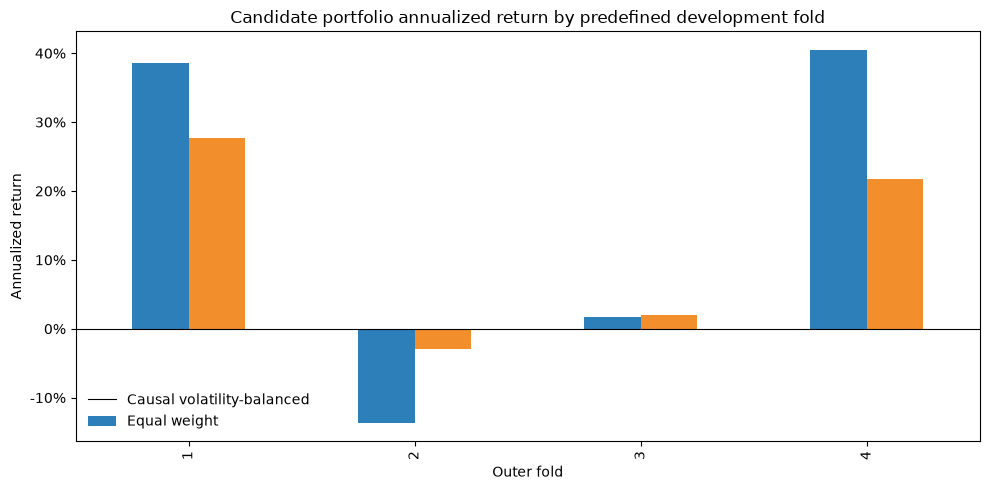

In [6]:
plot_frame = candidate_folds.pivot(
    index='fold', columns='strategy', values='annualized_return'
)
ax = plot_frame.plot.bar(figsize=(10, 5), color=['#2c7fb8', '#f28e2b'])
ax.axhline(0.0, color='black', linewidth=0.8)
ax.set_title('Candidate portfolio annualized return by predefined development fold')
ax.set_xlabel('Outer fold')
ax.set_ylabel('Annualized return')
ax.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
ax.legend(['Causal volatility-balanced', 'Equal weight'], frameon=False)
plt.tight_layout()
plt.show()

### Costed development equity

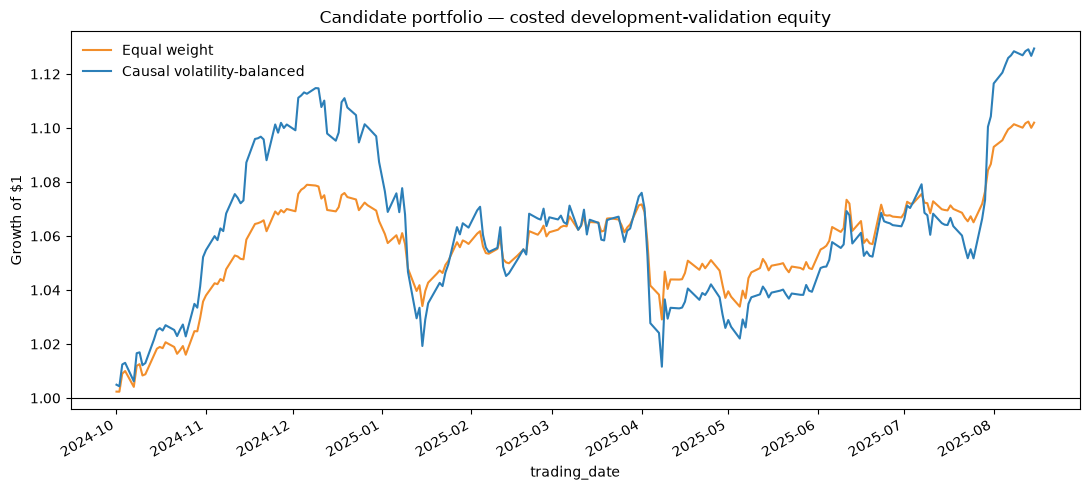

In [7]:
validation_mask = pd.Series(False, index=portfolios.index)
for fold in folds.itertuples():
    validation_mask.loc[
        pd.Timestamp(fold.validation_start):pd.Timestamp(fold.validation_end)
    ] = True
candidate_columns = [
    'candidate_sleeves_equal_weight',
    'candidate_sleeves_causal_volatility_balanced',
]
equity = (1.0 + portfolios.loc[validation_mask, candidate_columns]).cumprod()
ax = equity.plot(figsize=(11, 5), color=['#f28e2b', '#2c7fb8'])
ax.axhline(1.0, color='black', linewidth=0.8)
ax.set_title('Candidate portfolio — costed development-validation equity')
ax.set_ylabel('Growth of $1')
ax.legend(['Equal weight', 'Causal volatility-balanced'], frameon=False)
plt.tight_layout()
plt.show()

### Diversification diagnostics

In [8]:
validation_correlation = pd.read_csv(
    CANDIDATE / 'validation_correlation.csv', index_col=0
)
validation_correlation.loc[[
    'ml_cl_trend', 'session_mr_moving_average_deviation'
], [
    'ml_cl_trend', 'session_mr_moving_average_deviation'
]].round(3)

,ml_cl_trend,session_mr_moving_average_deviation
ml_cl_trend,1.000,0.454
session_mr_moving_average_deviation,0.454,1.000


## Takeaways

1. **There is a real development candidate:** CL linear trend plus the moving-average mean-reversion family produced a positive combined score in three of four folds after modeled costs.
2. **Do not fund every researched idea:** the all-sleeves combination was negative; diversification is useful only when the underlying sleeve has at least plausible development evidence.
3. **Prefer equal weight for the next stage:** it had the higher development Sharpe and smaller drawdown. The volatility-balanced version amplified the losing second fold.
4. **Fold 2 is the key weakness:** the equal-weight candidate lost 2.9% annualized in that fold. Regime and sleeve attribution should focus on explaining this period without tuning it away.
5. **Confidence: share with caveats.** The calculation and data boundary are verified, but selection reused development folds and CL was already screened. Freeze the candidate specification before any chronological locked evaluation.